# 子图
子图是核心功能， 一句话说明白，langgraph支持嵌套套娃结构，在一个langgraph的执行流程里面，允许某一个节点里面调用另外一个图，实现嵌套更加复杂的关系，整个叫做子图，如果在A里面嵌套B，B就是A的子图，

如果子图使用功能的时候，要避开Mermaid关键字，Mermaid美人鱼，  主要langgraph设定的关键字：  
subgraph, end, graph, flowchart, classDef  
也不要太简单， 还有个方法可以添加前缀或者后缀， 就不容易出现冲突的情况

怎么实现子图的调用，两种办法：
1. 直接在父图的节点函数里面直接调用invoke， subgraph是额外定义的子图B图，父子状态完全隔离，父节点看不到子节点中间状态的变化，手动调用定义谁等于谁，因为使用图的时候可以获取很多状态变化信息， 本质状态隔离
2. 还有办法，把子图 add node添加为父图的节点，  这样会完全共享状态字段，

先演示在节点函数里面调用子图

In [4]:
from typing import TypedDict

from langgraph.graph import StateGraph,START,END
from loguru import logger


#1. 构建子图
#1.1 声明子图的状态
class SubgraphState(TypedDict):
    raw_text:str #未清洗的文本
    stripped_text:str # 去除首尾的空格
    punctuated_text:str # 句尾添加句号

#1.2 声明子图的节点 -> 去除空格的节点
def subgraph_strip_node(state:SubgraphState) -> SubgraphState:
    raw_text = state["raw_text"]
    stripped_text = raw_text.strip()
    logger.info("调用子图中的strip节点")
    return {
        "stripped_text":stripped_text
    }

#1.3 添加句号的节点
def subgraph_punctuated_node(state:SubgraphState) -> SubgraphState:
    stripped_text = state["stripped_text"]
    punctuated_text = stripped_text + '。'
    logger.info("调用子图中的punctuated节点")
    return {
        "punctuated_text":punctuated_text
    }

#1.4 构建子图
builder = StateGraph(state_schema=SubgraphState)
builder.add_node("subgraph_strip_node",subgraph_strip_node)
builder.add_node("subgraph_punctuated_node",subgraph_punctuated_node)
builder.add_edge(START,"subgraph_strip_node")
builder.add_edge("subgraph_strip_node","subgraph_punctuated_node")
builder.add_edge("subgraph_punctuated_node",END)
subgraph = builder.compile()

res = subgraph.invoke({
    "raw_text":"   langgraph真有意思   "
})
print(res)



2026-09-19 09:47:08.405 | INFO     | __main__:subgraph_strip_node:18 - 调用子图中的strip节点
2026-09-19 09:47:08.406 | INFO     | __main__:subgraph_punctuated_node:27 - 调用子图中的punctuated节点


{'raw_text': '   langgraph真有意思   ', 'stripped_text': 'langgraph真有意思', 'punctuated_text': 'langgraph真有意思。'}


In [5]:
#2.构建父图
#2.1 声明状态
class ParentState(TypedDict):
    input_text:str
    cleaned_text:str

#2.2 声明节点 => 调用子图节点
def call_subgraph(state:ParentState)->ParentState:
    input_text = state["input_text"]
    res = subgraph.invoke({"raw_text":input_text})
    cleaned_text = res["punctuated_text"]   # 只是简单的把调用结果传到cleand_text
    return {
        "cleaned_text":cleaned_text
    }

#2.3 构建父图
parent_builder = StateGraph(state_schema=ParentState)
parent_builder.add_node("call_subgraph",call_subgraph)
parent_builder.add_edge(START,"call_subgraph")
parent_builder.add_edge("call_subgraph",END)

parent_graph = parent_builder.compile()

#2.4 调用父图 => 内部函数会调用子图
res = parent_graph.invoke({"input_text":"    langgraph真好玩   "})
print(res)

2026-09-19 09:47:14.463 | INFO     | __main__:subgraph_strip_node:18 - 调用子图中的strip节点
2026-09-19 09:47:14.464 | INFO     | __main__:subgraph_punctuated_node:27 - 调用子图中的punctuated节点


{'input_text': '    langgraph真好玩   ', 'cleaned_text': 'langgraph真好玩。'}


# 这种直接调用方法有问题，有些注意事项
要弄一些特殊方法，展示这种带嵌套结构的图



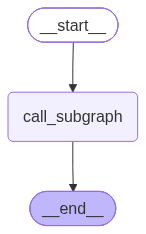

In [ ]:
display(parent_graph) # 直接打印父图，会发现只显示父图的节点，不显示子图

# 要采用额外的方法

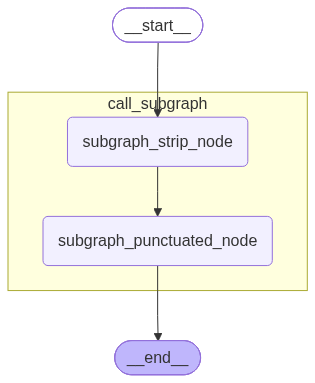

In [ ]:
from IPython.display import display,Image
display(
    Image(parent_graph.get_graph(xray=True).draw_mermaid_png())
) # 额外的方法来展示子图， xray=True自动递归回去子图， 然后.draw_mermaid_png化成图， 这样虽然在父图调用，但是把子图也打印出来了 



# 说明系统已经正确识别到了
为什么能解析，因为子图信息依赖于Langgraph对于节点函数代码的解析，
因为langgraph读到了 `res = subgraph.invoke({"raw_text": input_text})`，就能解析嵌套图的结构


错误用法，  不能在.invoke里面搞一堆连带的东西，不然无法感知子图（有时候解析不到）
```python
assistant_response = subgraph.invoke(
    {"messages": messages}
)["messages"][-1].content # 看不到 ×

subgraph_response = subgraph.invoke(
    {"messages": messages}
) 对√

assistant_response = subgraph_response["messages"][-1].content


```

In [ ]:
list(parent_graph.get_subgraphs()) # 去查看子图，用这个方式

[('call_subgraph',
  <langgraph.graph.state.CompiledStateGraph at 0x2165867e850>)]